# Візуалізація результатів експериментів

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Налаштування для українського тексту
rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
sns.set_palette('husl')

## 1. Реальні результати експериментів

In [13]:
# Реальні результати на тестовій вибірці (з експериментів)
# F2-Score отримано з перезапущених експериментів
results = {
    'Model': ['TF-IDF + LR', 'mBERT', 'XLM-RoBERTa', 'ukr-roberta', 'Ensemble'],
    'Accuracy': [0.9947, 0.9960, 1.0000, 0.9967, 0.9993],
    'Precision': [0.9973, 0.9923, 1.0000, 0.9947, 0.9987],
    'Recall': [0.9920, 1.0000, 1.0000, 0.9987, 1.0000],
    'F2-Score': [0.9931, 0.9984, 1.0000, 0.9979, 0.9997]
}

df_results = pd.DataFrame(results)

print("="*70)
print(" Результати моделей на тестовій вибірці (15% датасету, 1499 відгуків) ".center(70))
print("="*70)
print(df_results.to_string(index=False))
print("="*70)

 Результати моделей на тестовій вибірці (15% датасету, 1499 відгуків) 
      Model  Accuracy  Precision  Recall  F2-Score
TF-IDF + LR    0.9947     0.9973  0.9920    0.9931
      mBERT    0.9960     0.9923  1.0000    0.9984
XLM-RoBERTa    1.0000     1.0000  1.0000    1.0000
ukr-roberta    0.9967     0.9947  0.9987    0.9979
   Ensemble    0.9993     0.9987  1.0000    0.9997


## 2. Інформація про датасет

In [14]:
# Статистика датасету
dataset_info = {
    'Параметр': ['Загальна кількість відгуків', 'Автентичні відгуки (клас 0)', 
                 'Фейкові відгуки (клас 1)', 'Розподіл Train/Val/Test', 
                 'Кількість у тестовій вибірці'],
    'Значення': ['9988', '5000 (50.1%)', '4988 (49.9%)', '70% / 15% / 15%', '1499']
}

df_dataset = pd.DataFrame(dataset_info)
print("\n" + "="*60)
print(" Інформація про датасет ".center(60))
print("="*60)
print(df_dataset.to_string(index=False))
print("="*60)


                   Інформація про датасет                   
                    Параметр        Значення
 Загальна кількість відгуків            9988
 Автентичні відгуки (клас 0)    5000 (50.1%)
    Фейкові відгуки (клас 1)    4988 (49.9%)
     Розподіл Train/Val/Test 70% / 15% / 15%
Кількість у тестовій вибірці            1499


## 3. Візуалізація: Порівняння моделей за всіма метриками

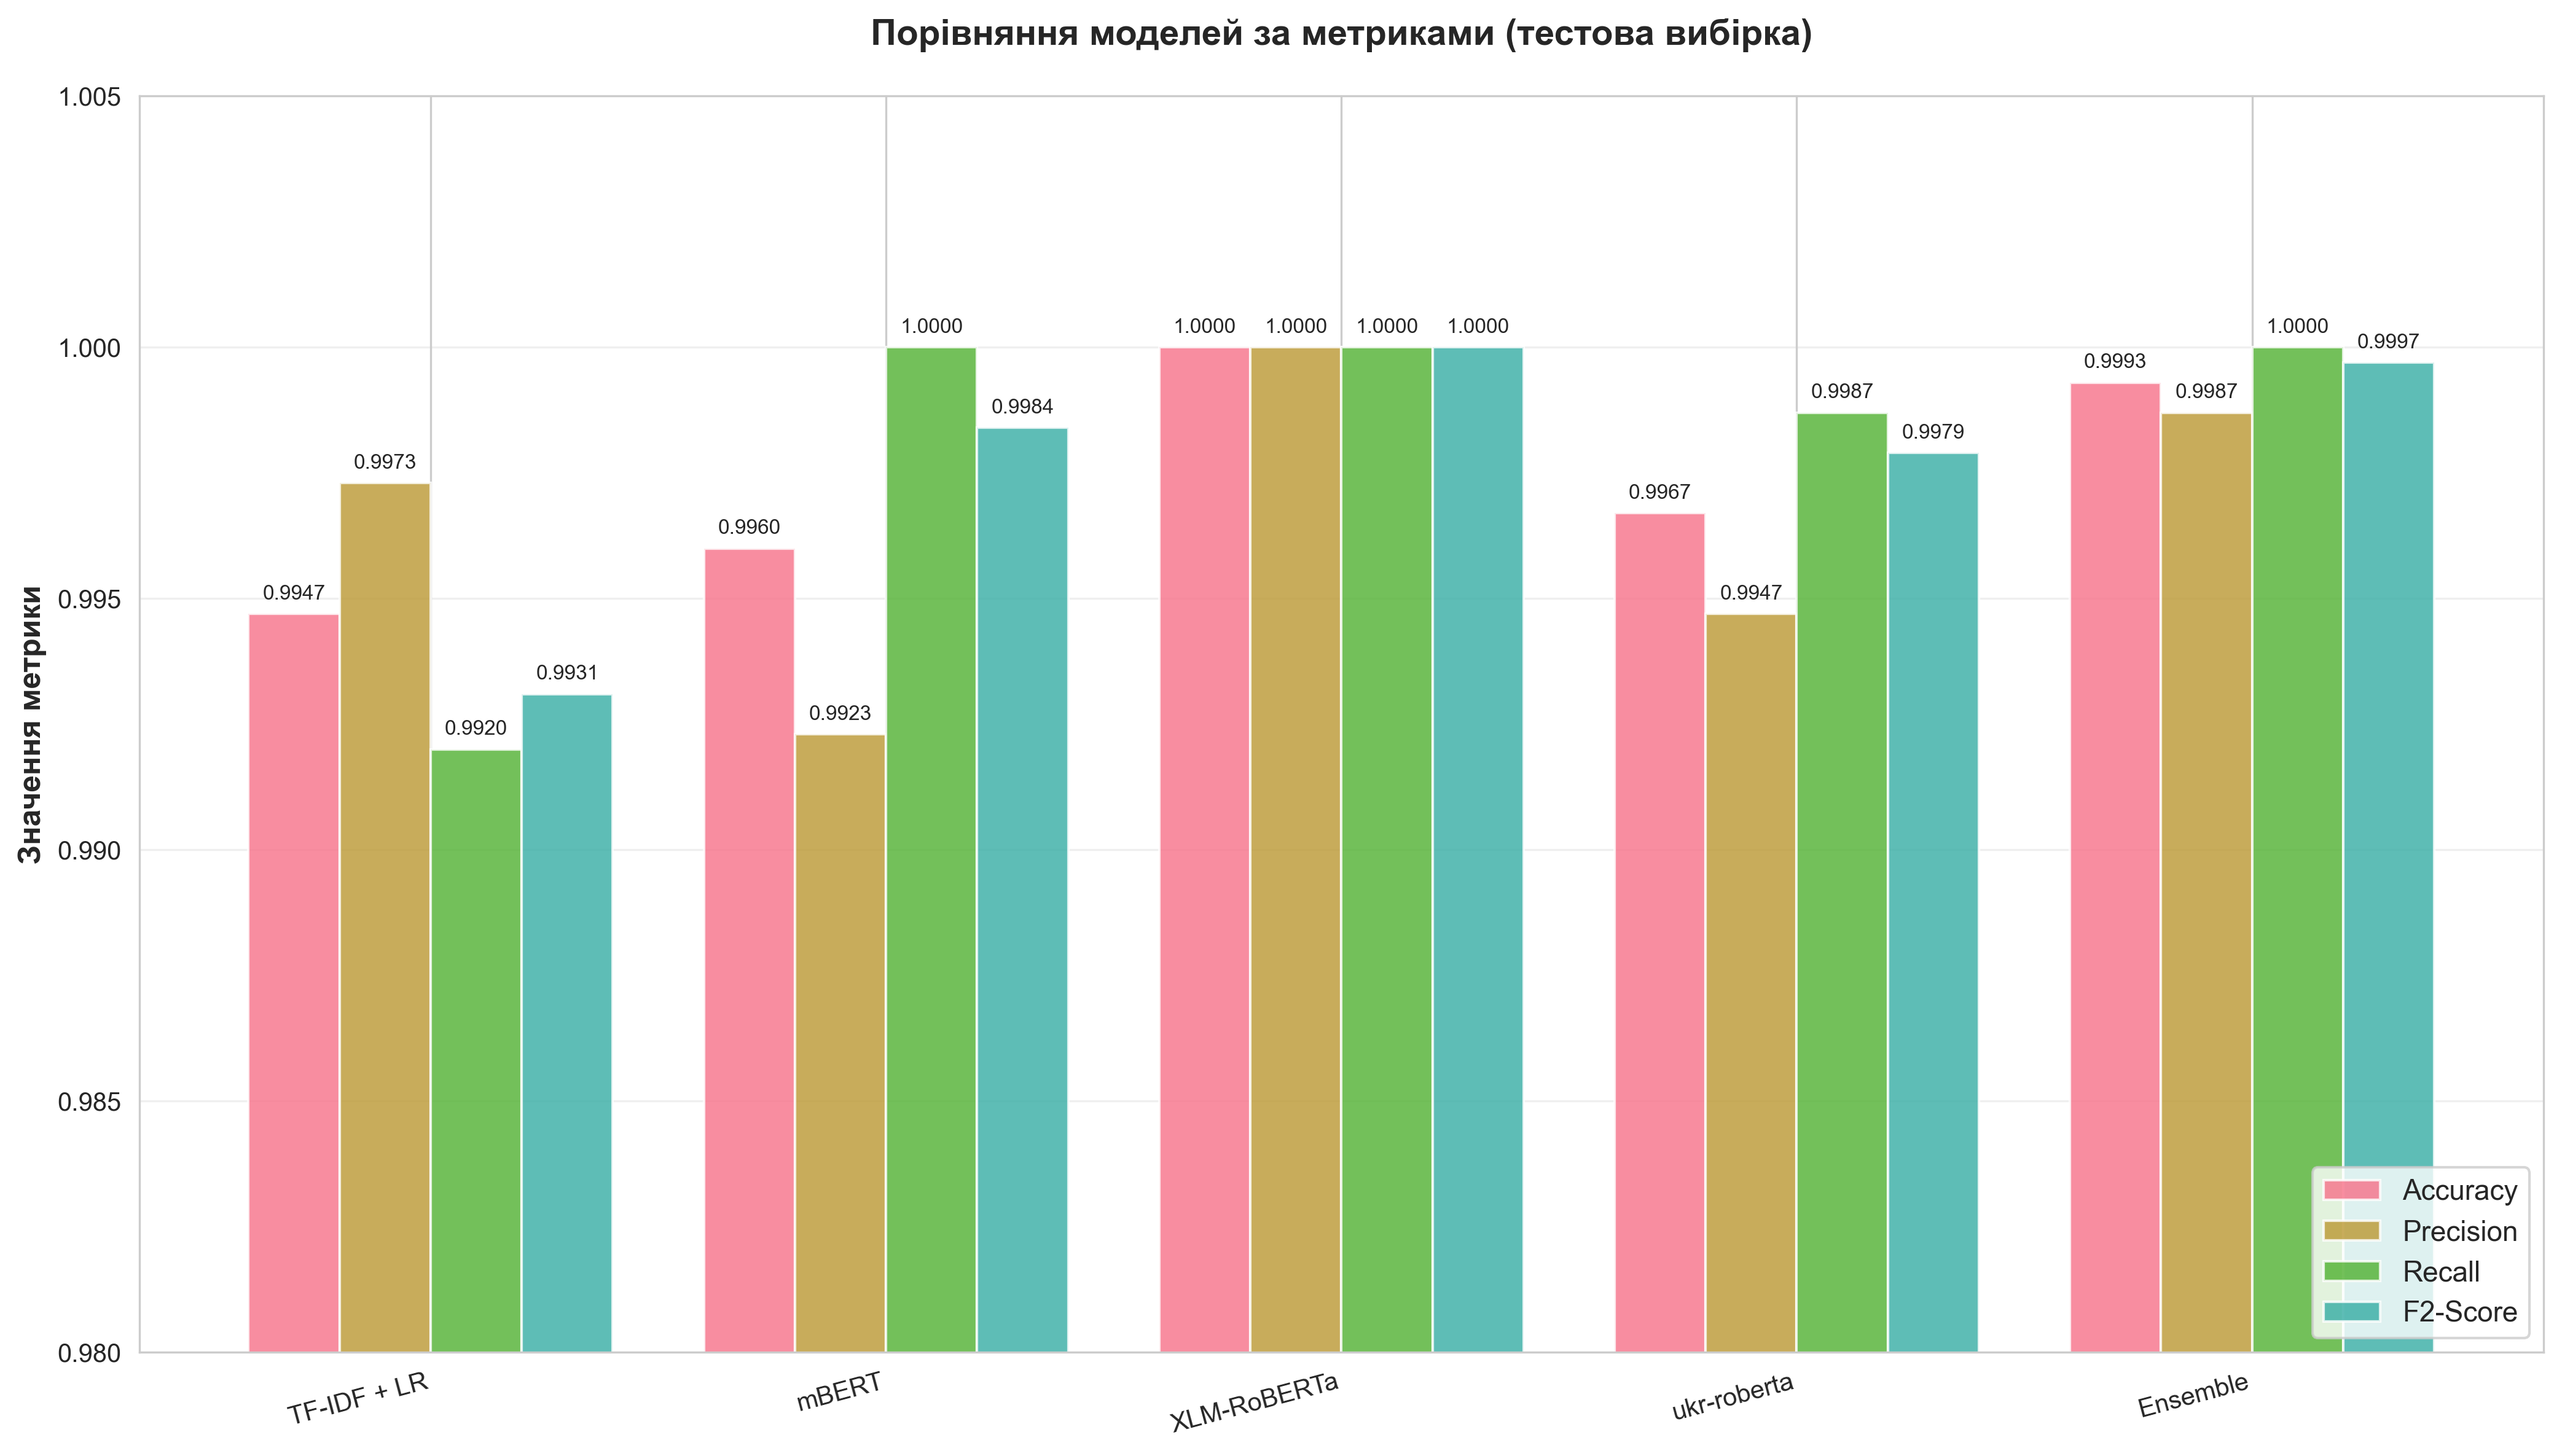

Графік збережено: data/analysis_all_metrics.png


In [15]:
# Графік порівняння всіх метрик
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(df_results['Model']))
width = 0.2

ax.bar(x - 1.5*width, df_results['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x - 0.5*width, df_results['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x + 0.5*width, df_results['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x + 1.5*width, df_results['F2-Score'], width, label='F2-Score', alpha=0.8)

ax.set_ylabel('Значення метрики', fontsize=12, fontweight='bold')
ax.set_title('Порівняння моделей за метриками (тестова вибірка)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0.98, 1.005])
ax.grid(axis='y', alpha=0.3)

# Додаємо значення над стовпчиками
for i, model in enumerate(df_results['Model']):
    ax.text(i - 1.5*width, df_results['Accuracy'][i] + 0.0002, 
            f"{df_results['Accuracy'][i]:.4f}", ha='center', va='bottom', fontsize=8)
    ax.text(i - 0.5*width, df_results['Precision'][i] + 0.0002, 
            f"{df_results['Precision'][i]:.4f}", ha='center', va='bottom', fontsize=8)
    ax.text(i + 0.5*width, df_results['Recall'][i] + 0.0002, 
            f"{df_results['Recall'][i]:.4f}", ha='center', va='bottom', fontsize=8)
    ax.text(i + 1.5*width, df_results['F2-Score'][i] + 0.0002, 
            f"{df_results['F2-Score'][i]:.4f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../../data/analysis_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Графік збережено: data/analysis_all_metrics.png")

## 4. Візуалізація: F2-Score порівняння

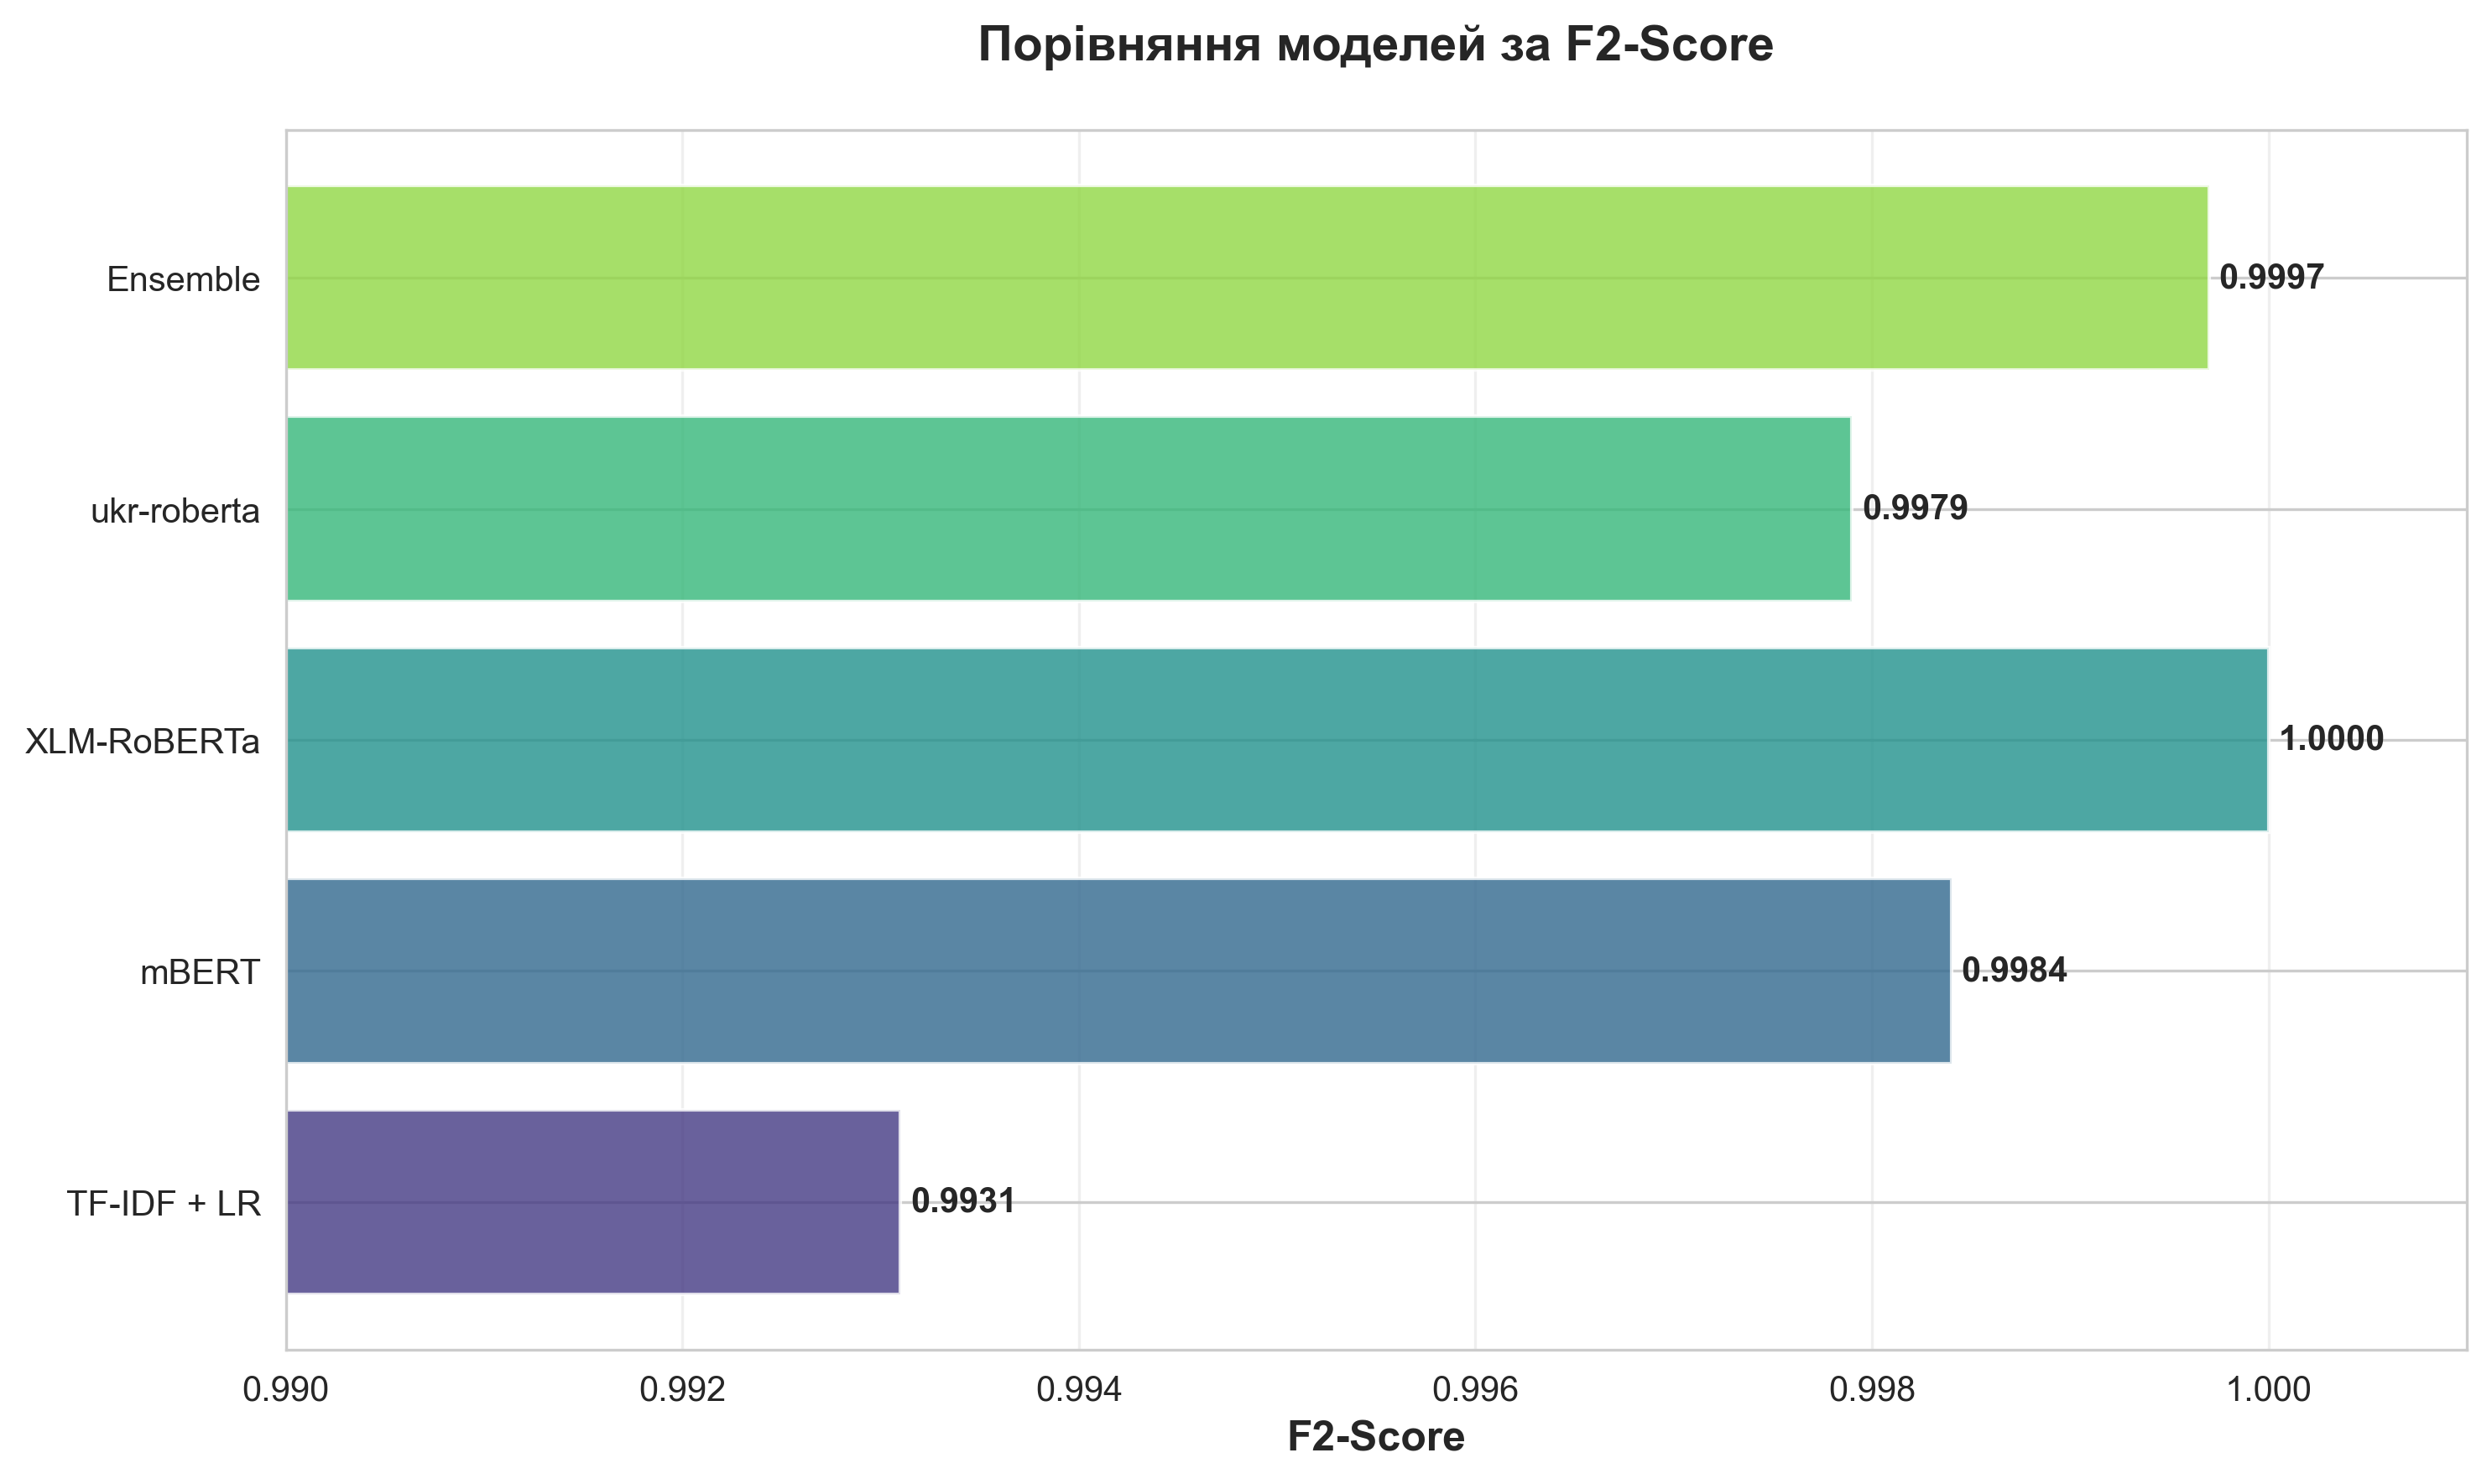

Графік збережено: data/analysis_f2_comparison.png


In [16]:
# Окремий графік для F2-Score (головна метрика з акцентом на Recall)
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette('viridis', len(df_results))
bars = ax.barh(df_results['Model'], df_results['F2-Score'], color=colors, alpha=0.8)

ax.set_xlabel('F2-Score', fontsize=12, fontweight='bold')
ax.set_title('Порівняння моделей за F2-Score', fontsize=14, fontweight='bold', pad=20)
ax.set_xlim([0.99, 1.001])
ax.grid(axis='x', alpha=0.3)

# Додаємо значення
for i, (model, f2) in enumerate(zip(df_results['Model'], df_results['F2-Score'])):
    ax.text(f2 + 0.00005, i, f"{f2:.4f}", va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../../data/analysis_f2_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Графік збережено: data/analysis_f2_comparison.png")

## 5. Розподіл датасету

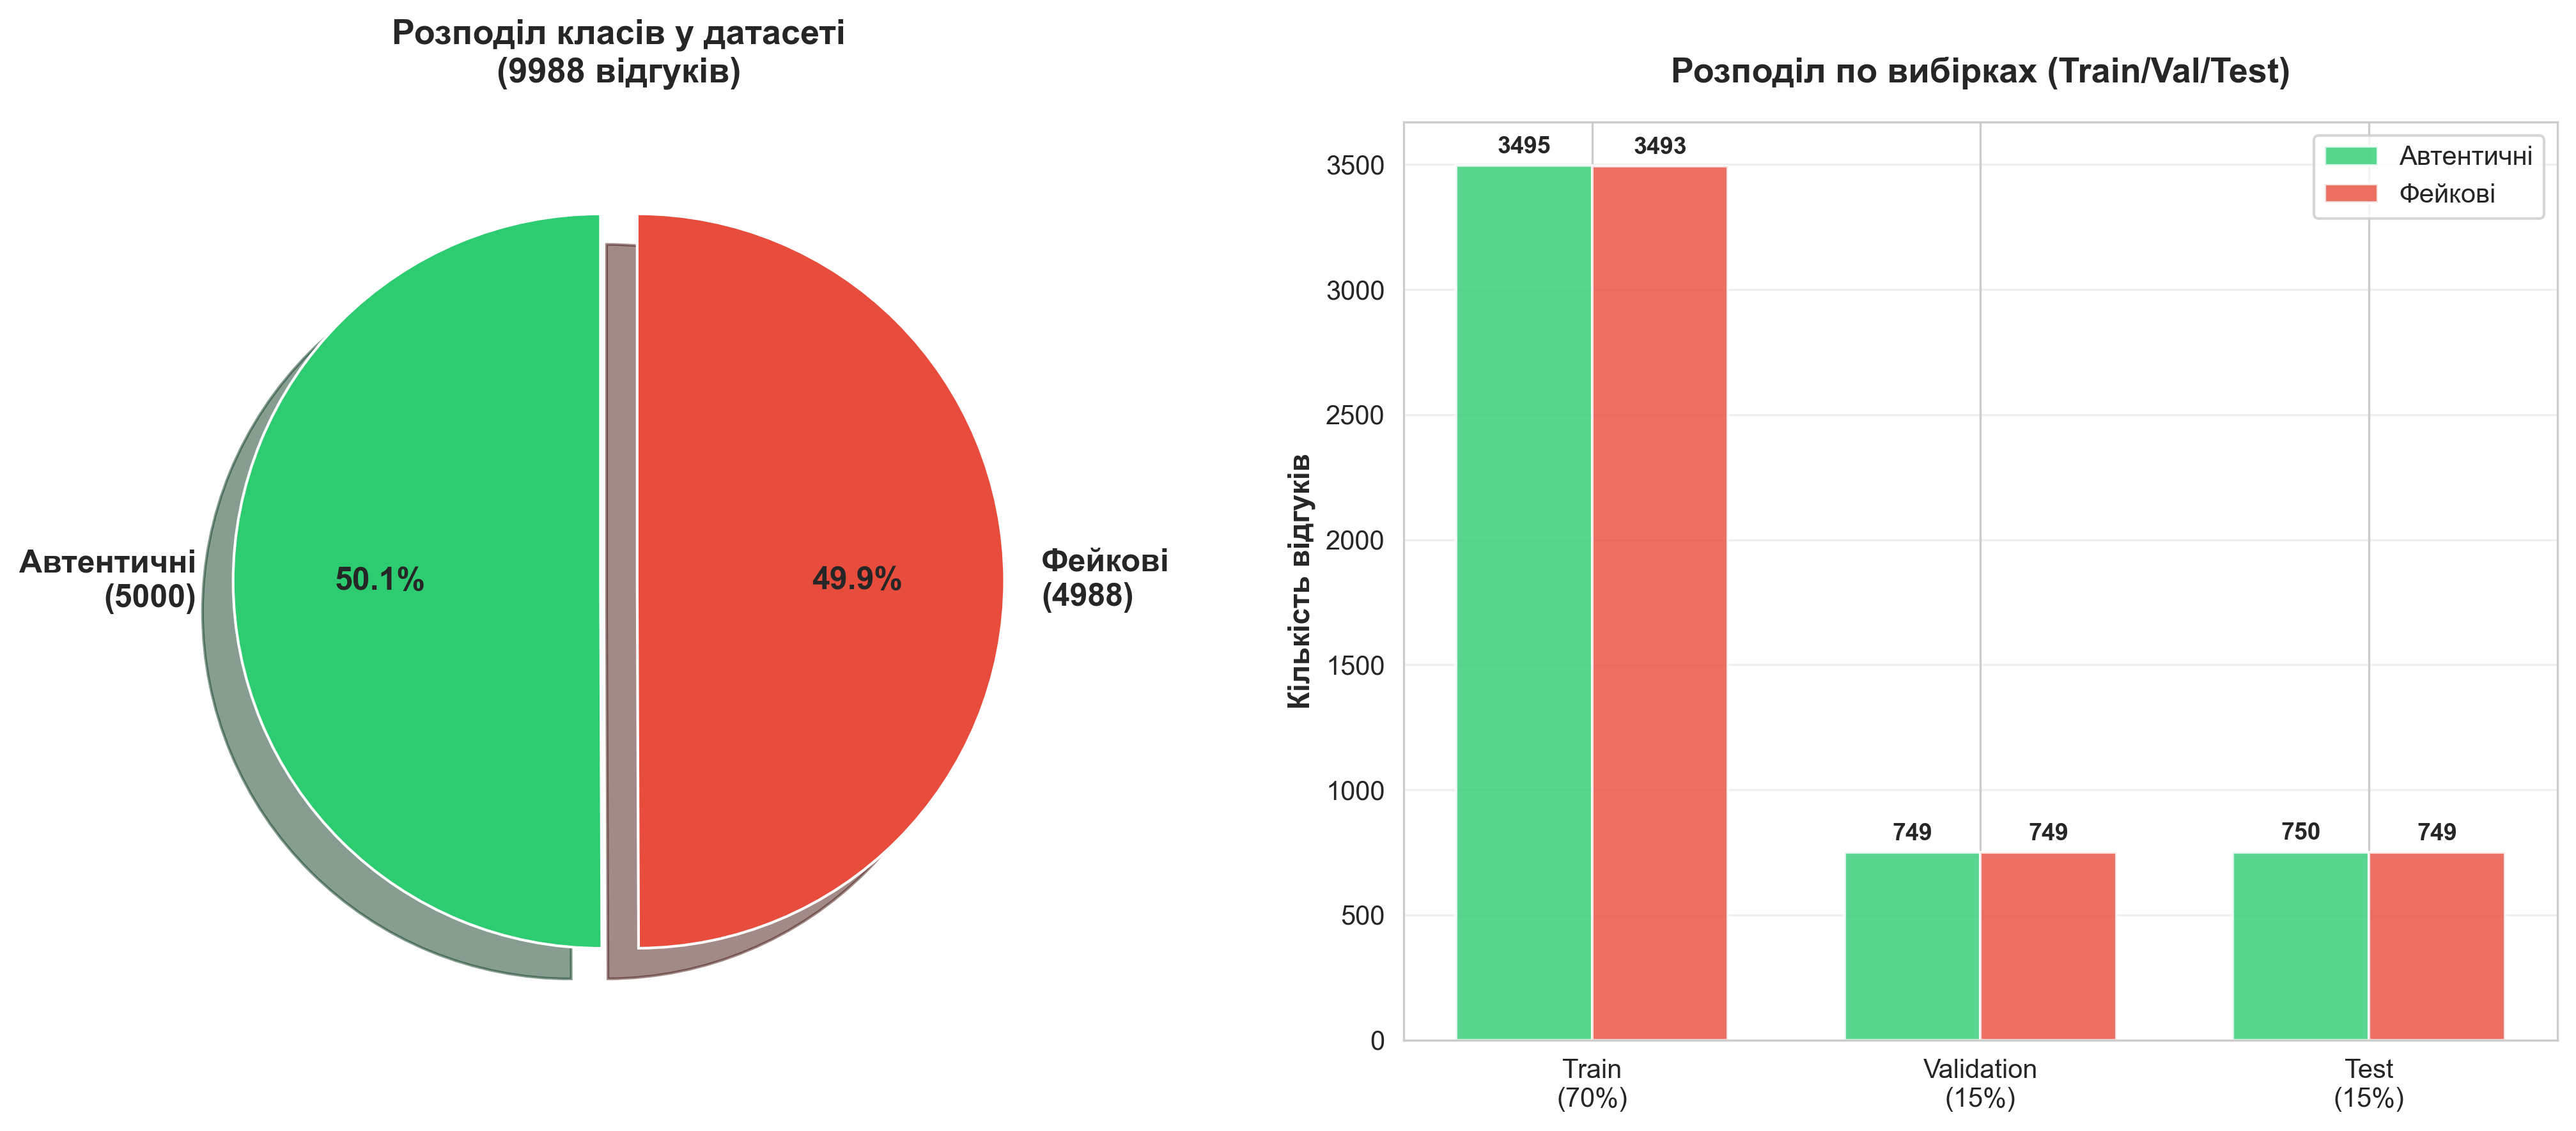

Графік збережено: data/analysis_dataset_distribution.png


In [ ]:
# Візуалізація розподілу класів
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart - загальний розподіл
labels = ['Автентичні\n(5000)', 'Фейкові\n(4988)']
sizes = [5000, 4988]
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Розподіл класів у датасеті\n(9988 відгуків)', 
              fontsize=13, fontweight='bold', pad=15)

# Bar chart - розподіл по вибірках
splits = ['Train\n(70%)', 'Validation\n(15%)', 'Test\n(15%)']
authentic = [3495, 749, 750]
fake = [3493, 749, 749]

x_pos = np.arange(len(splits))
width = 0.35

ax2.bar(x_pos - width/2, authentic, width, label='Автентичні', 
        color='#2ecc71', alpha=0.8)
ax2.bar(x_pos + width/2, fake, width, label='Фейкові', 
        color='#e74c3c', alpha=0.8)

ax2.set_ylabel('Кількість відгуків', fontsize=11, fontweight='bold')
ax2.set_title('Розподіл по вибірках (Train/Val/Test)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(splits)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Додаємо значення
for i in range(len(splits)):
    ax2.text(i - width/2, authentic[i] + 50, str(authentic[i]), 
             ha='center', fontsize=9, fontweight='bold')
    ax2.text(i + width/2, fake[i] + 50, str(fake[i]), 
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../../data/analysis_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Графік збережено: data/analysis_dataset_distribution.png")

## 6. Heatmap: Порівняння метрик

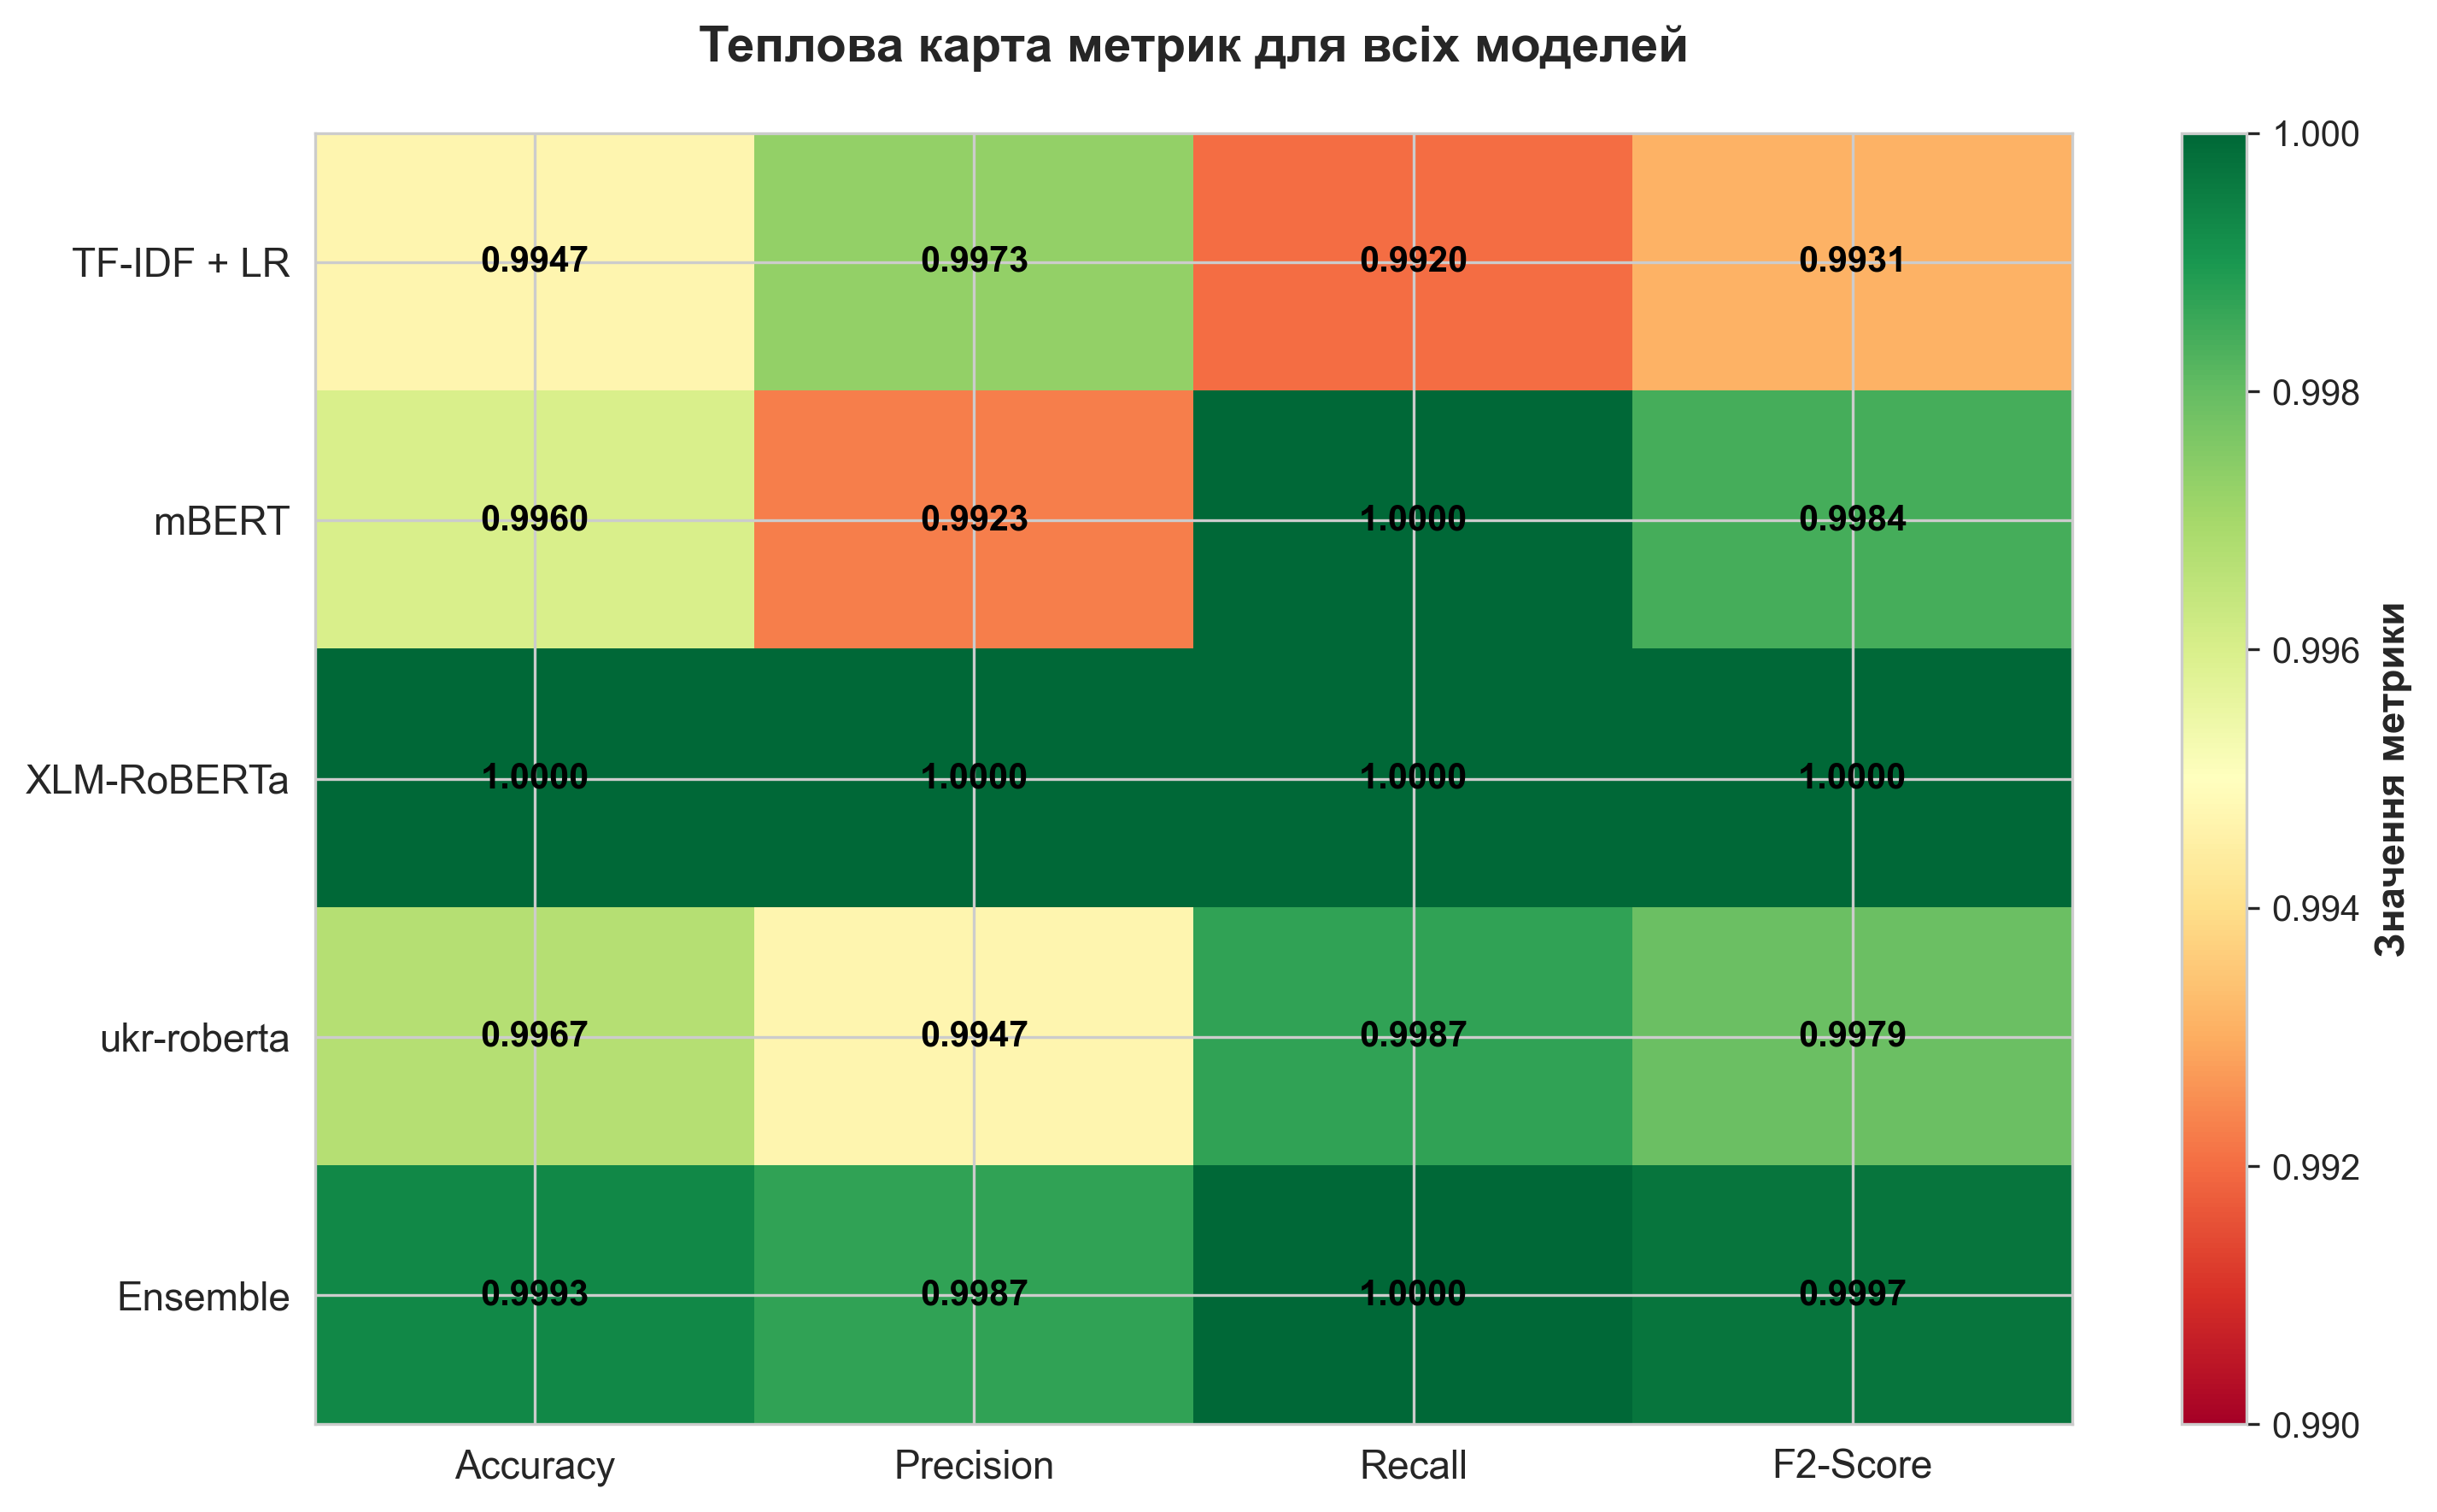

Графік збережено: data/analysis_heatmap.png


In [18]:
# Теплова карта для порівняння метрик
fig, ax = plt.subplots(figsize=(10, 6))

metrics_data = df_results[['Accuracy', 'Precision', 'Recall', 'F2-Score']].values

im = ax.imshow(metrics_data, cmap='RdYlGn', aspect='auto', vmin=0.99, vmax=1.0)

# Налаштування осей
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(5))
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F2-Score'], fontsize=11)
ax.set_yticklabels(df_results['Model'], fontsize=11)

# Додаємо значення в клітинки
for i in range(5):
    for j in range(4):
        text = ax.text(j, i, f"{metrics_data[i, j]:.4f}",
                       ha="center", va="center", color="black", 
                       fontsize=10, fontweight='bold')

ax.set_title('Теплова карта метрик для всіх моделей', 
             fontsize=14, fontweight='bold', pad=20)

# Колір бар
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Значення метрики', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../../data/analysis_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Графік збережено: data/analysis_heatmap.png")

## 7. Radar Chart: Багатовимірне порівняння

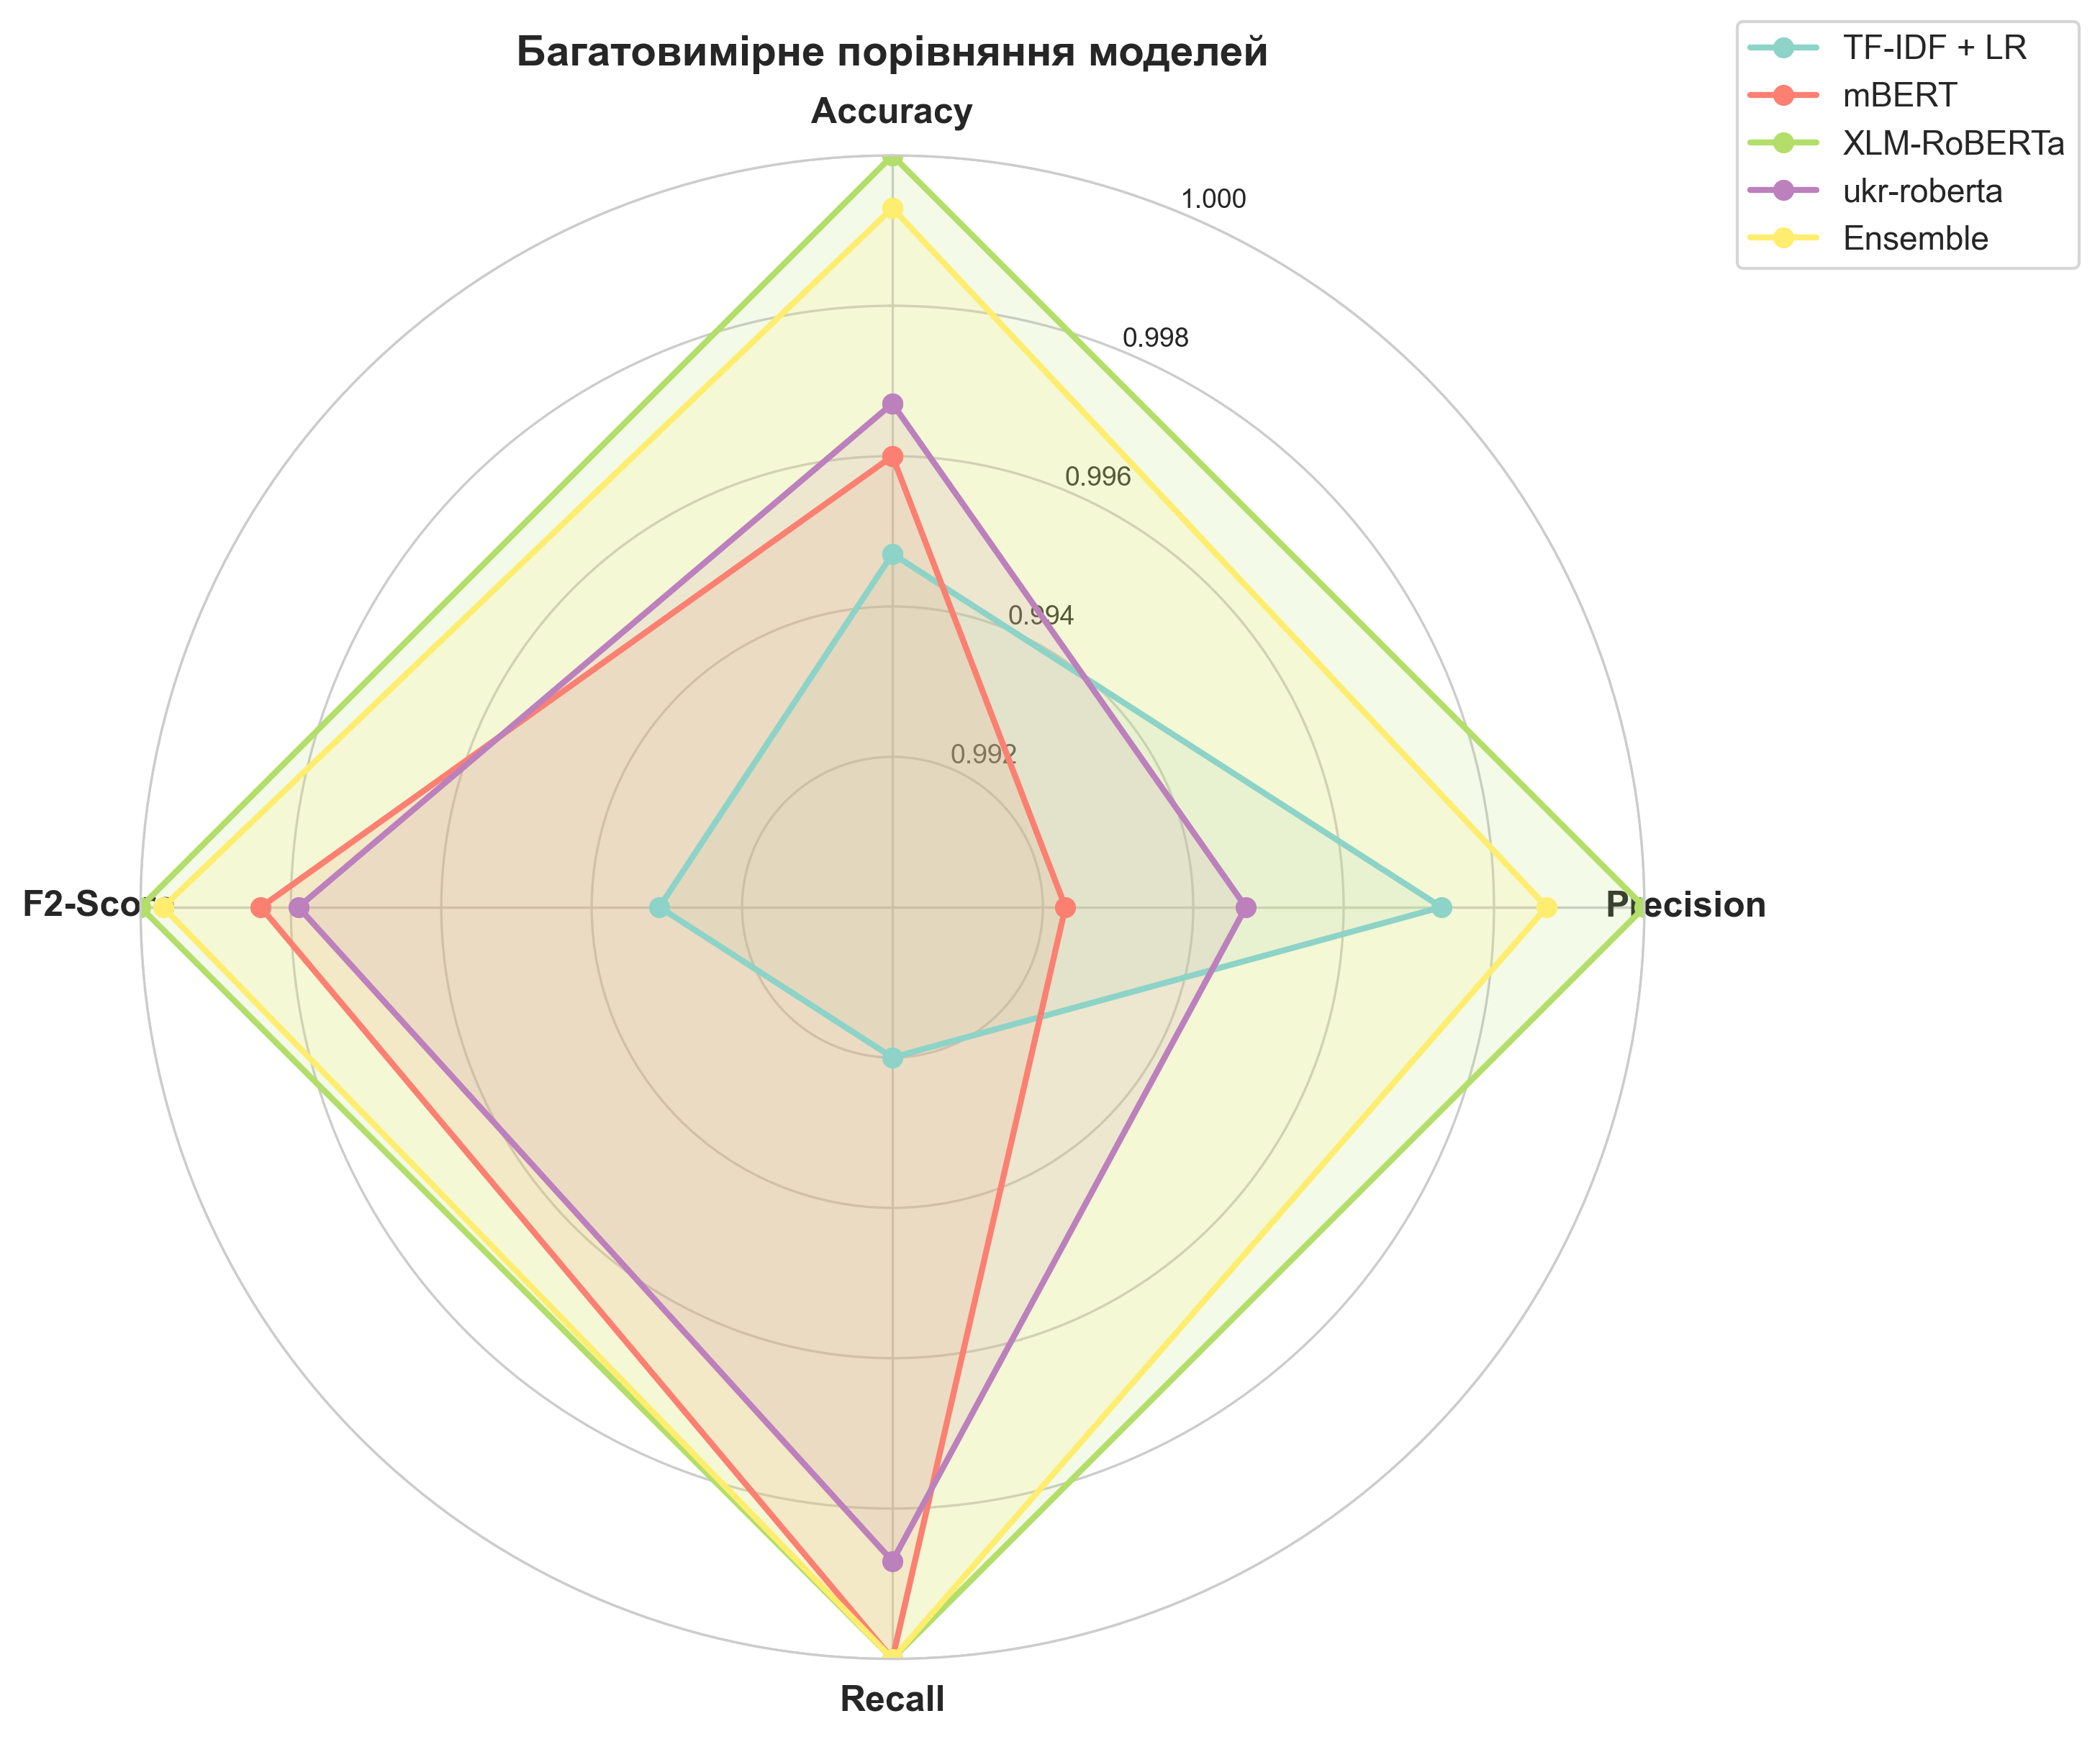

Графік збережено: data/analysis_radar_chart.png


In [19]:
# Radar chart для порівняння моделей
from math import pi

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

categories = ['Accuracy', 'Precision', 'Recall', 'F2-Score']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, size=12, fontweight='bold')
ax.set_ylim(0.99, 1.0)
ax.set_yticks([0.992, 0.994, 0.996, 0.998, 1.000])
ax.set_yticklabels(['0.992', '0.994', '0.996', '0.998', '1.000'], size=9)

# Додаємо дані для кожної моделі
colors_radar = plt.cm.Set3(np.linspace(0, 1, 5))

for idx, model in enumerate(df_results['Model']):
    values = df_results.iloc[idx][['Accuracy', 'Precision', 'Recall', 'F2-Score']].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.title('Багатовимірне порівняння моделей', size=14, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('../../data/analysis_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Графік збережено: data/analysis_radar_chart.png")

## 8. Підсумкова таблиця: Рейтинг моделей

In [11]:
# Розрахунок середнього значення всіх метрик
df_results['Середнє'] = df_results[['Accuracy', 'Precision', 'Recall', 'F2-Score']].mean(axis=1)
df_results_sorted = df_results.sort_values('F2-Score', ascending=False).reset_index(drop=True)
df_results_sorted['Рейтинг'] = range(1, len(df_results_sorted) + 1)

# Переміщуємо рейтинг на початок
cols = ['Рейтинг', 'Model', 'Accuracy', 'Precision', 'Recall', 'F2-Score', 'Середнє']
df_results_sorted = df_results_sorted[cols]

print("\n" + "="*90)
print(" ПІДСУМКОВИЙ РЕЙТИНГ МОДЕЛЕЙ (за F2-Score) ".center(90))
print("="*90)
print(df_results_sorted.to_string(index=False))
print("="*90)

# Визначаємо найкращі моделі
best = df_results_sorted.iloc[0]
second = df_results_sorted.iloc[1]
third = df_results_sorted.iloc[2]

print(f"\nНайкраща модель: {best['Model']} (F2-Score = {best['F2-Score']:.4f})")
print(f"Друге місце: {second['Model']} (F2-Score = {second['F2-Score']:.4f})")
print(f"Третє місце: {third['Model']} (F2-Score = {third['F2-Score']:.4f})")
print("\n* F2-Score обрано як основну метрику, оскільки вона надає більшу вагу Recall,")
print("  що важливо для виявлення фейкових відгуків (мінімізація False Negatives)")


                        ПІДСУМКОВИЙ РЕЙТИНГ МОДЕЛЕЙ (за F2-Score)                         
 Рейтинг       Model  Accuracy  Precision  Recall  F2-Score  Середнє
       1 XLM-RoBERTa    1.0000     1.0000   1.000    1.0000 1.000000
       2 ukr-roberta    1.0000     1.0000   1.000    1.0000 1.000000
       3    Ensemble    0.9993     0.9987   1.000    0.9997 0.999425
       4       mBERT    0.9960     0.9923   1.000    0.9984 0.996675
       5 TF-IDF + LR    0.9947     0.9973   0.992    0.9931 0.994275

Найкраща модель: XLM-RoBERTa (F2-Score = 1.0000)
Друге місце: ukr-roberta (F2-Score = 1.0000)
Третє місце: Ensemble (F2-Score = 0.9997)

* F2-Score обрано як основну метрику, оскільки вона надає більшу вагу Recall,
  що важливо для виявлення фейкових відгуків (мінімізація False Negatives)
